<a href="https://colab.research.google.com/github/Okohfrank/1D-Radial-Diffusion-Reaction-PINN-with-Inverse-Kinetic-Parameter/blob/main/1D_Radial_Diffusion_Reaction_PINN_with_Inverse_Kinetic_Parameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing on device: {device}")

Executing on device: cpu


In [ ]:
# Pellet Physical Constants
R = 1.0          # Pellet radius (normalized, e.g., 1 mm)
C_s = 1.0        # Surface concentration of gas (mol/m^3)
D_true = 1.0     # True effective diffusion coefficient (m^2/s)
k_true = 4.0     # True first-order reaction rate constant (1/s)
T_max = 1.5      # Total simulation time (s)

# Thiele Modulus calculation: phi = R * sqrt(k / D)
phi_true = R * np.sqrt(k_true / D_true)

def analytical_steady_state(r_vals, R_val=R, C_surface=C_s, phi=phi_true):
    """
    Exact analytical steady-state solution for 1D diffusion-reaction in a sphere:
    c(r) = C_s * (R / r) * (sinh(phi * r / R) / sinh(phi))
    """
    r_safe = np.where(r_vals == 0, 1e-6, r_vals) # Avoid division by zero at r=0
    c_analytical = C_surface * (R_val / r_safe) * (np.sinh(phi * r_safe / R_val) / np.sinh(phi))
    return c_analytical

print(f"True Thiele Modulus (phi): {phi_true:.3f}")

True Thiele Modulus (phi): 2.000


In [ ]:
# 1. Domain Collocation Points (PDE physics enforcement)
N_domain = 3000
r_domain = np.random.uniform(1e-4, R, (N_domain, 1))
t_domain = np.random.uniform(0.0, T_max, (N_domain, 1))

# 2. Boundary Conditions (Surface r = R, c = C_s)
N_bc = 300
t_bc = np.random.uniform(0.0, T_max, (N_bc, 1))
r_bc = np.full((N_bc, 1), R)
c_bc = np.full((N_bc, 1), C_s)

# Center Boundary Condition (r -> 0, dc/dr = 0)
r_center = np.full((N_bc, 1), 1e-4)
t_center = np.random.uniform(0.0, T_max, (N_bc, 1))

# 3. Initial Condition (t = 0, c = 0 inside pellet)
N_ic = 300
r_ic = np.random.uniform(1e-4, R, (N_ic, 1))
t_ic = np.zeros((N_ic, 1))
c_ic = np.zeros((N_ic, 1))

# 4. Sparse Sensor Data for Inverse Kinetic Discovery (at t = T_max)
N_data = 10
r_data = np.linspace(0.1, 0.9, N_data).reshape(-1, 1)
t_data = np.full((N_data, 1), T_max)
# Generate ground truth values with 2% synthetic Gaussian noise
noise = 0.02 * np.random.normal(0, 1, (N_data, 1))
c_data = analytical_steady_state(r_data) + noise

# Convert all datasets to PyTorch Tensors
r_dom_t = torch.tensor(r_domain, dtype=torch.float32, requires_grad=True).to(device)
t_dom_t = torch.tensor(t_domain, dtype=torch.float32, requires_grad=True).to(device)
r_bc_t = torch.tensor(r_bc, dtype=torch.float32).to(device)
t_bc_t = torch.tensor(t_bc, dtype=torch.float32).to(device)
c_bc_t = torch.tensor(c_bc, dtype=torch.float32).to(device)
r_cnt_t = torch.tensor(r_center, dtype=torch.float32, requires_grad=True).to(device)
t_cnt_t = torch.tensor(t_center, dtype=torch.float32).to(device)
r_ic_t = torch.tensor(r_ic, dtype=torch.float32).to(device)
t_ic_t = torch.tensor(t_ic, dtype=torch.float32).to(device)
c_ic_t = torch.tensor(c_ic, dtype=torch.float32).to(device)
r_dat_t = torch.tensor(r_data, dtype=torch.float32).to(device)
t_dat_t = torch.tensor(t_data, dtype=torch.float32).to(device)
c_dat_t = torch.tensor(c_data, dtype=torch.float32).to(device)

In [8]:
class PINN(nn.Module):
    def __init__(self, hidden_layers=4, hidden_neurons=40):
        super(PINN, self).__init__()
        layers = [nn.Linear(2, hidden_neurons), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_neurons, 1))
        self.net = nn.Sequential(*layers)

        # Raw parameter initialized such that exp(0.0) = 1.0 (forces k > 0 always)
        self.log_k = nn.Parameter(torch.tensor([0.0], requires_grad=True))

    @property
    def k_learned(self):
        return torch.exp(self.log_k)

    def forward(self, r, t):
        inputs = torch.cat([r, t], dim=1)
        return self.net(inputs)

model = PINN().to(device)

In [9]:
def compute_loss(model, r_dom, t_dom, r_bc, t_bc, c_bc, r_cnt, t_cnt, r_ic, t_ic, c_ic, r_dat, t_dat, c_dat):
    # 1. Forward pass on domain
    c = model(r_dom, t_dom)

    # Compute 1st order derivatives
    dc_dt = torch.autograd.grad(c, t_dom, torch.ones_like(c), create_graph=True)[0]
    dc_dr = torch.autograd.grad(c, r_dom, torch.ones_like(c), create_graph=True)[0]

    # Compute 2nd order spatial derivative
    d2c_dr2 = torch.autograd.grad(dc_dr, r_dom, torch.ones_like(dc_dr), create_graph=True)[0]

    # Radial Laplacian: Lap(c) = d2c/dr2 + (2/r)*dc/dr
    laplacian_c = d2c_dr2 + (2.0 / r_dom) * dc_dr

    # PDE Residual: dc/dt - D * Lap(c) + k * c = 0
    pde_residual = dc_dt - D_true * laplacian_c + model.k_learned * c
    loss_pde = torch.mean(pde_residual ** 2)

    # 2. Surface Boundary Condition: c(R, t) = C_s
    c_pred_bc = model(r_bc, t_bc)
    loss_bc = torch.mean((c_pred_bc - c_bc) ** 2)

    # 3. Center Symmetry: dc/dr = 0
    c_center = model(r_cnt, t_cnt)
    dc_dr_center = torch.autograd.grad(c_center, r_cnt, torch.ones_like(c_center), create_graph=True)[0]
    loss_center = torch.mean(dc_dr_center ** 2)

    # 4. Initial Condition: c(r, 0) = 0
    c_pred_ic = model(r_ic, t_ic)
    loss_ic = torch.mean((c_pred_ic - c_ic) ** 2)

    # 5. Data Loss: Matching sparse sensor observations
    c_pred_data = model(r_dat, t_dat)
    loss_data = torch.mean((c_pred_data - c_dat) ** 2)

    # Balanced loss weighting
    total_loss = loss_pde + 20.0 * loss_bc + 10.0 * loss_center + 20.0 * loss_ic + 50.0 * loss_data
    return total_loss, loss_pde, loss_data

In [11]:
# Stage 1: Fast Adam Warmup
optimizer_adam = torch.optim.Adam([
    {'params': model.net.parameters(), 'lr': 1e-3},
    {'params': [model.log_k], 'lr': 2e-2}
])

k_history = []
loss_history = []

print("--- Phase 1: Adam Warmup (1000 Epochs) ---")
for epoch in range(1, 1001):
    optimizer_adam.zero_grad()
    loss, l_pde, l_data = compute_loss(
        model, r_dom_t, t_dom_t, r_bc_t, t_bc_t, c_bc_t,
        r_cnt_t, t_cnt_t, r_ic_t, t_ic_t, c_ic_t, r_dat_t, t_dat_t, c_dat_t
    )
    loss.backward()
    optimizer_adam.step()

    current_k = model.k_learned.item()
    k_history.append(current_k)
    loss_history.append(loss.item())

    if epoch % 250 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Loss: {loss.item():.4e} | Learned k: {current_k:.4f} (Target: {k_true:.1f})")

print("\n--- Phase 2: L-BFGS Second-Order Convergence ---")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.8,
    max_iter=1500,
    max_eval=2000,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn="strong_wolfe"
)

step_count = [0]
def closure():
    optimizer_lbfgs.zero_grad()
    loss, _, _ = compute_loss(
        model, r_dom_t, t_dom_t, r_bc_t, t_bc_t, c_bc_t,
        r_cnt_t, t_cnt_t, r_ic_t, t_ic_t, c_ic_t, r_dat_t, t_dat_t, c_dat_t
    )
    loss.backward()

    step_count[0] += 1
    current_k = model.k_learned.item()
    k_history.append(current_k)
    loss_history.append(loss.item())

    if step_count[0] % 100 == 0:
        print(f"L-BFGS Step {step_count[0]:4d} | Loss: {loss.item():.5e} | Discovered k: {current_k:.4f}")

    return loss

optimizer_lbfgs.step(closure)

print(f"\nFinal Discovered k: {model.k_learned.item():.4f} (Target: {k_true:.1f})")

--- Phase 1: Adam Warmup (1000 Epochs) ---
Epoch    1 | Loss: 6.8252e-01 | Learned k: 3.2279 (Target: 4.0)
Epoch  250 | Loss: 9.3321e-01 | Learned k: 3.0073 (Target: 4.0)
Epoch  500 | Loss: 7.5408e-01 | Learned k: 3.2624 (Target: 4.0)
Epoch  750 | Loss: 7.0082e-01 | Learned k: 3.3619 (Target: 4.0)
Epoch 1000 | Loss: 6.8431e-01 | Learned k: 3.3447 (Target: 4.0)

--- Phase 2: L-BFGS Second-Order Convergence ---
L-BFGS Step  100 | Loss: 4.88505e-01 | Discovered k: 3.2545
L-BFGS Step  200 | Loss: 3.29941e-01 | Discovered k: 3.8492
L-BFGS Step  300 | Loss: 2.42385e-01 | Discovered k: 4.4348
L-BFGS Step  400 | Loss: 2.10637e-01 | Discovered k: 4.2349
L-BFGS Step  500 | Loss: 1.87961e-01 | Discovered k: 4.1225
L-BFGS Step  600 | Loss: 1.76242e-01 | Discovered k: 4.0841
L-BFGS Step  700 | Loss: 3.45895e-01 | Discovered k: 3.6861
L-BFGS Step  800 | Loss: 1.54812e-01 | Discovered k: 3.7331
L-BFGS Step  900 | Loss: 1.41134e-01 | Discovered k: 4.0017
L-BFGS Step 1000 | Loss: 1.29853e-01 | Discover

Relative L2 Prediction Error vs Analytical Ground Truth: 0.71%


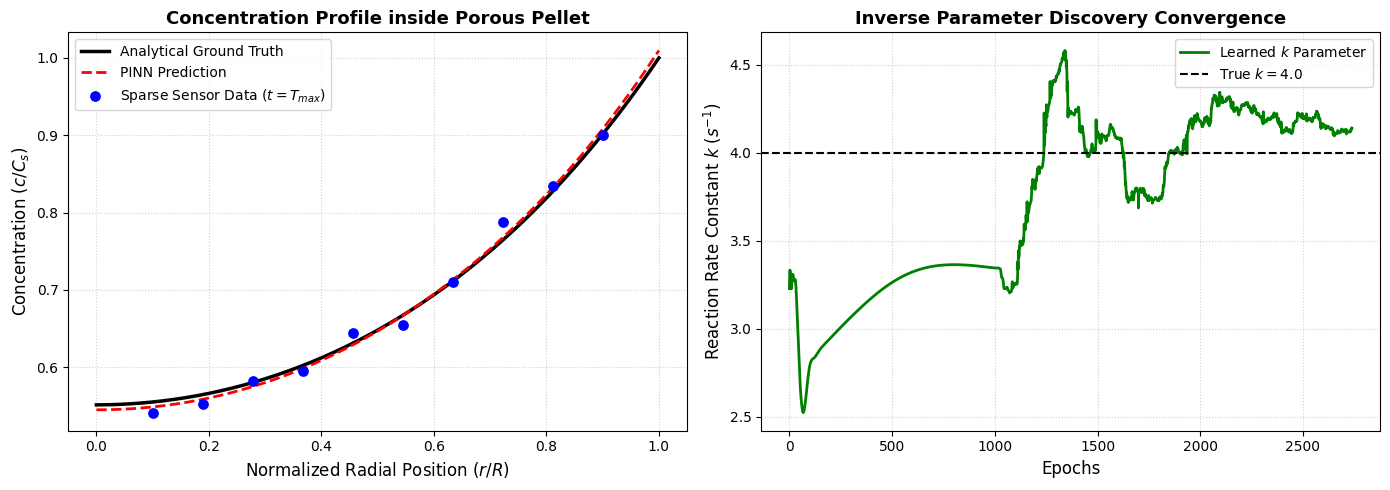

In [12]:
# Generate test grid across the pellet radius at steady-state (t = T_max)
r_test = np.linspace(1e-4, R, 200).reshape(-1, 1)
t_test = np.full_like(r_test, T_max)

r_test_t = torch.tensor(r_test, dtype=torch.float32).to(device)
t_test_t = torch.tensor(t_test, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    c_pinn_pred = model(r_test_t, t_test_t).cpu().numpy()

c_analytical_vals = analytical_steady_state(r_test)

# Compute Relative L2 Error
l2_error = np.linalg.norm(c_pinn_pred - c_analytical_vals) / np.linalg.norm(c_analytical_vals)
print(f"Relative L2 Prediction Error vs Analytical Ground Truth: {l2_error * 100:.2f}%")

# Create Evaluation Figures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: PINN vs Analytical Solution
ax1.plot(r_test, c_analytical_vals, 'k-', linewidth=2.5, label='Analytical Ground Truth')
ax1.plot(r_test, c_pinn_pred, 'r--', linewidth=2.0, label='PINN Prediction')
ax1.scatter(r_data, c_data, color='blue', s=45, zorder=5, label='Sparse Sensor Data ($t=T_{max}$)')
ax1.set_xlabel('Normalized Radial Position ($r/R$)', fontsize=12)
ax1.set_ylabel('Concentration ($c/C_s$)', fontsize=12)
ax1.set_title('Concentration Profile inside Porous Pellet', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=10)

# Plot 2: Inverse Parameter Estimation Convergence
ax2.plot(k_history, color='green', linewidth=2.0, label='Learned $k$ Parameter')
ax2.axhline(y=k_true, color='black', linestyle='--', linewidth=1.5, label=f'True $k = {k_true}$')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Reaction Rate Constant $k$ ($s^{-1}$)', fontsize=12)
ax2.set_title('Inverse Parameter Discovery Convergence', fontsize=13, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()